In [100]:
## Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from datetime import datetime
from surprise import Dataset, reader
from sklearn.datasets import load_wine
from sklearn.metrics.pairwise import cosine_similarity


In [101]:
## Load data
wine = load_wine(as_frame=True)
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)

chickwts = pd.read_csv(
    "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/chickwts.csv",
    index_col=0
)

usarrests = pd.read_csv(
    "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/USArrests.csv",
    index_col=0
)

In [102]:
## data information
print(f"wine_df info:\n{wine_df.info()}")
print(f"chickwts info:\n{chickwts.info()}")
print(f"usarrests info:\n{usarrests.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [103]:
## Check for null values
print(f"wine_df:\n{wine_df.isnull().sum()}")
print(f"chickwts:\n{chickwts.isnull().sum()}")
print(f"usarrests:\n{usarrests.isnull().sum()}")

wine_df:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64
chickwts:
weight    0
feed      0
dtype: int64
usarrests:
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


In [104]:
## Check for duplicates
print(f"wine_df:\n{wine_df.duplicated().sum()}")
print(f"chickwts:\n{chickwts.duplicated().sum()}")
print(f"usarrests:\n{usarrests.duplicated().sum()}")

# drop duplicates
chickwts = chickwts.drop_duplicates()
print(f"chickwts:\n{chickwts.duplicated().sum()}")

wine_df:
0
chickwts:
1
usarrests:
0
chickwts:
0


## 1. Wine data for classification using PCA & KNN

### Dataset Overview:
178 samples of wine grown in the same region of Italy, from 3 different cultivars (classes). 13 chemical/physical features per sample: alcohol, malic acid, ash, alcalinity of ash, magnesium, total phenols, flavanoids, nonflavanoid phenols, proanthocyanins, color intensity, hue, OD280/OD315, and proline.<br>

### Objective:
To predict the class of wine (cultivar) based on its chemical composition by first applying Principal Component Analysis (PCA) to reduce the dimensionality of the 13 correlated features while retaining 95% of the variance, and then using a K-Nearest Neighbors (KNN) classifier on the resulting principal components to accurately classify wine samples into their respective cultivars.<br>

In [105]:
wine_df_1 = wine_df.copy()
y_categorical = pd.Series(wine.target_names[wine.target])

encoder = LabelEncoder()
X = wine_df_1
y = encoder.fit_transform(y_categorical)
y_categorical

0      class_0
1      class_0
2      class_0
3      class_0
4      class_0
        ...   
173    class_2
174    class_2
175    class_2
176    class_2
177    class_2
Length: 178, dtype: object

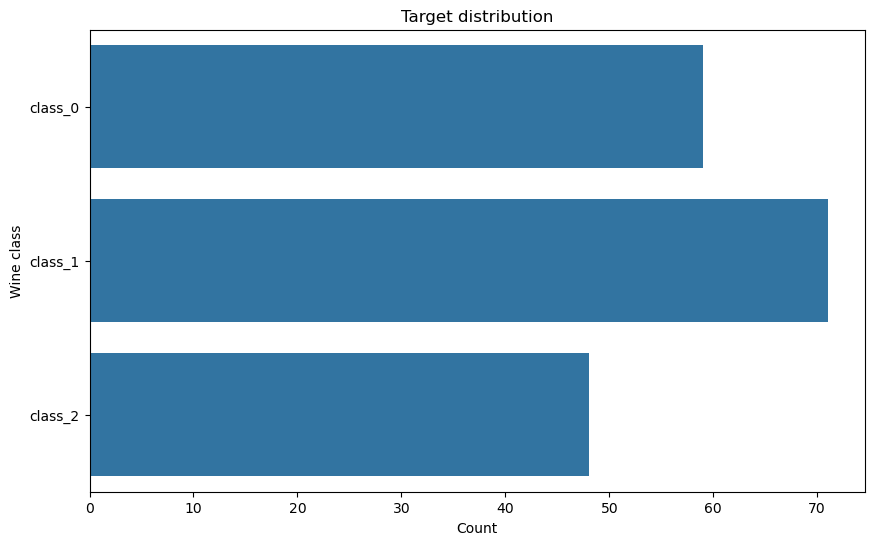

In [106]:
## Visualize target distribution
plt.figure(figsize=(10, 6))
sns.countplot(y=y_categorical)
plt.title("Target distribution")
plt.xlabel("Count")
plt.ylabel("Wine class")
plt.show()


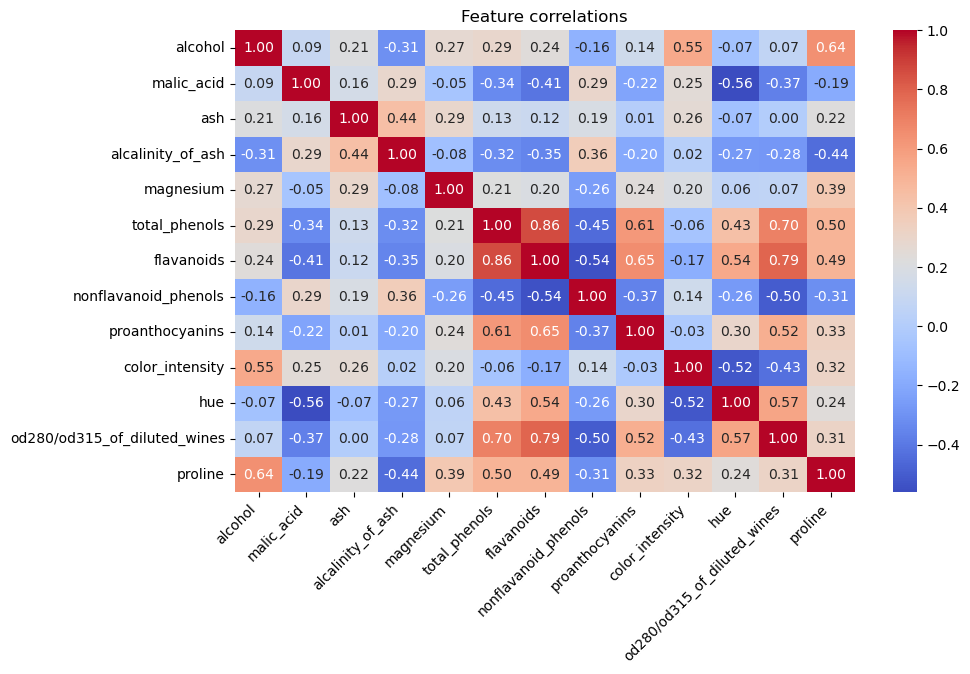

In [107]:
## Correlation visualization
plt.figure(figsize= (10,6))
sns.heatmap(wine_df_1.corr(), cmap= "coolwarm", annot= True, fmt= ".2f")
plt.title("Feature correlations")
plt.xticks(rotation= 45, ha= "right")
plt.show()

### Observations
- Flavanoids: Total phenols (0.86) — very strongly correlated. Makes sense chemically: flavanoids are a subclass of phenolic compounds.
- Flavanoids: OD280/OD315 (0.79) and Total phenols ↔ OD280/OD315 (0.70) — also strong, since this measure reflects phenolic/protein content.
- Flavanoids:  Proanthocyanins (0.65) and Total phenols ↔ Proanthocyanins (0.61) — moderate-strong, another phenolic-family relationship.
- Hue: Malic acid (-0.56) and Color intensity ↔ Hue (-0.52) — negative relationships: wines with more malic acid tend to have lower hue values; more intense color tends to mean lower hue.
- Alcohol: Proline (0.64) and Alcohol ↔ Color intensity (0.55) — alcohol content tracks with proline and color strength.
- Many features (ash, magnesium, nonflavanoid phenols) show weak correlations (near 0) with most others — they carry more independent information.

**Conclusion**: There's clear redundancy among the phenolic-related features (total phenols, flavanoids, proanthocyanins, OD280/OD315) — this is exactly the kind of multicollinearity PCA is good at compressing into fewer components.

In [108]:
## Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [109]:
## Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
## PCA model
pca = PCA(
    n_components= 0.95,
    random_state= 42
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [111]:
print(f"\nOriginal number of features: {X_train.shape[1]}")
print(f"Number of components retaining 95% variance: {pca.n_components_}")
print(f"Explained variance ratio (cumulative): {np.sum(pca.explained_variance_ratio_):.4f}")


Original number of features: 13
Number of components retaining 95% variance: 10
Explained variance ratio (cumulative): 0.9624


In [112]:
## using grid search
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "metric": ["euclidean", "manhattan", "minkowski"],
    "weights": ["uniform", "distance"]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid= param_grid,
    cv= 5,
    scoring= "accuracy",
    n_jobs = -1

)

grid_search.fit(X_train_pca, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [1, 2, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,18


In [113]:
print("\nBest parameters found:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Best parameters found: {'metric': 'euclidean', 'n_neighbors': 18, 'weights': 'uniform'}
Best cross-validation accuracy: 0.9791


In [114]:
## Fit and predict using the best model

best_knn = grid_search.best_estimator_
best_knn.fit(X_train_pca, y_train)
y_pred = best_knn.predict(X_test_pca)

In [115]:
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



### Interpretation
100% accuracy across all 3 classes, 36/36 test samples correct.<br>
This suggests the wine cultivars occupy well-separated clusters in the reduced PCA space — i.e., the top principal components (likely dominated by the phenolic group + color/alcohol/proline, based on the correlations) capture enough class-discriminating signal that neighboring points in PCA space are reliably the same cultivar.<br>

## 2. Recommendation Systems

### chickwts Dataset – Overview
A dataset recording the weights of young chickens fed different feed supplements. <br>
Structure: 71 observations, 2 columns:<br>

weight — the chick's weight (in grams) at six weeks old<br>
feed — the type of feed supplement given (categorical: casein, horsebean, linseed, meatmeal, soybean, sunflower)<br>

### Objective:
To build a simple recommendation system by standardizing the chick weight feature, reducing it via PCA to a single principal component, and computing cosine similarity between feed types based on their PCA-transformed weight profiles — recommending feed types with the most similar resulting chick growth patterns.

In [116]:
print(chickwts.head())
print(f"chickwts info:\n")
print(chickwts.info())
print(f"\nchickwts statistics:\n")
print(chickwts.describe())

          weight       feed
rownames                   
1            179  horsebean
2            160  horsebean
3            136  horsebean
4            227  horsebean
5            217  horsebean
chickwts info:

<class 'pandas.core.frame.DataFrame'>
Index: 70 entries, 1 to 71
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   weight  70 non-null     int64 
 1   feed    70 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.6+ KB
None

chickwts statistics:

           weight
count   70.000000
mean   261.500000
std     78.620857
min    108.000000
25%    203.750000
50%    259.000000
75%    324.250000
max    423.000000


In [117]:
## Check for null values
chickwts.isnull().sum()

weight    0
feed      0
dtype: int64

In [118]:
## Check for duplicates
chickwts.duplicated().sum()

np.int64(0)

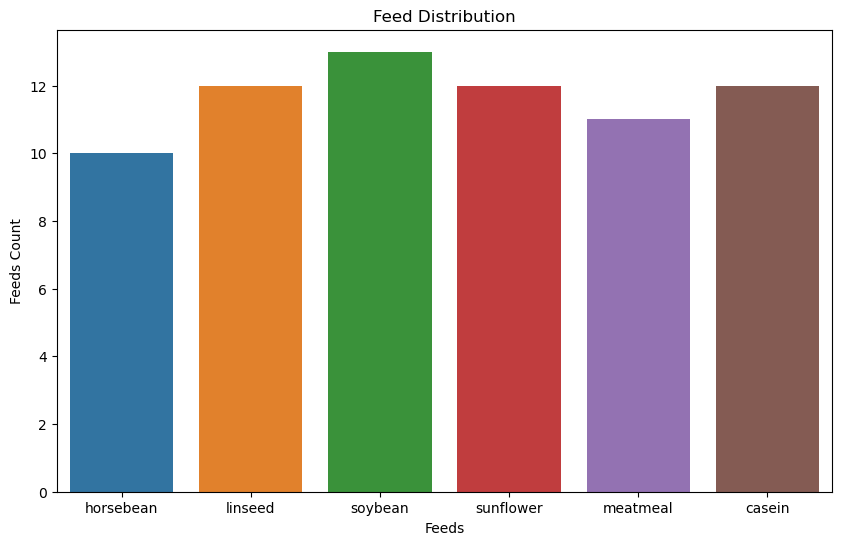

In [119]:
## Feed distribution
plt.figure(figsize= (10, 6))
sns.countplot(data=chickwts, x="feed", hue= "feed")
plt.title("Feed Distribution")
plt.xlabel("Feeds")
plt.ylabel("Feeds Count")
plt.show()

In [120]:
## Scaling the numeric feature
scaler = StandardScaler()
chickwts['weight_scaled'] = scaler.fit_transform(chickwts[['weight']])

In [121]:
## Using PCA

pca = PCA(n_components=1)
chickwts['PC1'] = pca.fit_transform(chickwts[['weight_scaled']])

print(f"\nExplained variance ratio: {pca.explained_variance_ratio_[0]:.4f}")


Explained variance ratio: 1.0000


In [122]:
## Create a new DataFrame grouped by feed type

feed_profile = chickwts.groupby('feed')['PC1'].mean().reset_index()
print("\nAverage PC1 score per feed type:")
print(feed_profile)


Average PC1 score per feed type:
        feed       PC1
0     casein  0.795356
1  horsebean -1.297765
2    linseed -0.547675
3   meatmeal  0.197408
4    soybean -0.194630
5  sunflower  0.863682


In [123]:
# Reshape PC1 values into a 2D array needed for cosine_similarity.
feed_vectors = feed_profile['PC1'].values.reshape(-1, 1)

similarity_matrix = cosine_similarity(feed_vectors)

# Put into a labeled DataFrame for readability
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_profile['feed'],
    columns=feed_profile['feed']
)

print("\nCosine Similarity Matrix between Feed Types:")
print(similarity_df.round(3))


Cosine Similarity Matrix between Feed Types:
feed       casein  horsebean  linseed  meatmeal  soybean  sunflower
feed                                                               
casein        1.0       -1.0     -1.0       1.0     -1.0        1.0
horsebean    -1.0        1.0      1.0      -1.0      1.0       -1.0
linseed      -1.0        1.0      1.0      -1.0      1.0       -1.0
meatmeal      1.0       -1.0     -1.0       1.0     -1.0        1.0
soybean      -1.0        1.0      1.0      -1.0      1.0       -1.0
sunflower     1.0       -1.0     -1.0       1.0     -1.0        1.0


In [124]:
# Recommend similar feeds
def recommend_similar_feed(feed_name, similarity_df, top_n=2):
    """
    Given a feed type, recommend the top_n most similar feeds
    based on cosine similarity of their PCA-transformed weight profiles.
    """
    if feed_name not in similarity_df.index:
        raise ValueError(f"'{feed_name}' not found in feed types.")
    
    # Get similarity scores for the given feed, excluding itself
    scores = similarity_df[feed_name].drop(index=feed_name)
    
    # Sort descending and take top_n
    top_matches = scores.sort_values(ascending=False).head(top_n)
    
    return top_matches

In [125]:
# Example usage
example_feed = 'casein'
recommendations = recommend_similar_feed(example_feed, similarity_df, top_n=2)

print(f"\nTop recommended feeds similar to '{example_feed}':")
print(recommendations)


Top recommended feeds similar to 'casein':
feed
meatmeal     1.0
sunflower    1.0
Name: casein, dtype: float64


### Conclusion
Using PCA-reduced (1 component) standardized chick weights, cosine similarity was computed between the six feed types.<br>
Since each feed type was represented by a single scalar value (average PC1 score), cosine similarity effectively grouped feeds into two broad categories: those associated with above-average weight gain (positive PC1) and those associated with below-average weight gain (negative PC1) feeds within the same group returned similarity scores close to 1.0, while feeds across groups returned similarity scores close to -1.0 or 0.
This means casein, meatmeal, and sunflower tend to produce heavier chicks, while horsebean and linseed tend to produce lighter chicks — so the recommendation system essentially rediscovered this known feed-effectiveness grouping through similarity scoring rather than an ANOVA-style mean comparison.

### Recommendation:

For practical feed selection: Farms aiming to maximize chick weight gain should prioritize feeds in the "high-weight" similarity cluster (e.g., if casein is the benchmark, its top recommended matches are the feeds worth substituting or comparing against for similar growth outcomes).<br>
Because only 1 principal component was used, cosine similarity here largely reflects the sign of the standardized weight relative to the mean rather than nuanced closeness in a true multi-dimensional sense. This means the similarity scores are somewhat coarse.<br>

## 3. Clustering with K means   and GMM

#### USArrests Dataset – Overview
A classic dataset containing statistics on violent crime rates for all 50 US states (as of 1973). It's one of the most widely used datasets in statistics for teaching PCA and clustering, originally built into R (datasets::USArrests).<br>
Features (4 total):

Murder — murder arrests per 100,000 residents<br>
Assault — assault arrests per 100,000 residents<br>
UrbanPop — percentage of the population living in urban areas<br>
Rape — rape arrests per 100,000 residents<br>

Structure: 50 rows (one per state), 4 numeric columns — no target/label column, making it an unsupervised learning dataset by nature.<br>

#### Objective
To explore patterns and natural groupings among U.S. states based on their violent crime rates and urbanization levels by applying Principal Component Analysis (PCA) to reduce the four correlated features into a smaller set of components, and then using clustering techniques in this case K-Means / GMM on the reduced data to identify states with similar crime and urbanization profiles  without relying on any predefined labels.

In [126]:
## Data preview
print(f"Dataset info:\n{usarrests.info()}")
print(f"\nDataset Statistics:\n{usarrests.describe()}")

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB
Dataset info:
None

Dataset Statistics:
         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  14.474763   9.366385
min     0.80000   45.000000  32.000000   7.300000
25%     4.07500  109.000000  54.500000  15.075000
50%     7.25000  159.000000  66.000000  20.100000
75%    11.25000  249.000000  77.750000  26.175000
max    17.40000  337.000000  91.000000  46.000000


In [127]:
## Check for null values
usarrests.isnull().sum()

Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [128]:
## Check for duplicates
usarrests.duplicated().sum()

np.int64(0)

In [129]:
## scaling the data
usarrests_copy = usarrests.copy()
scaler = StandardScaler()
usarrests_std = scaler.fit_transform(usarrests_copy)

In [130]:
## Clustering for K means
inertia_values = []
K_values = list(range(1,11))

for k in K_values:
    knn= KMeans(n_clusters= k,
                random_state= 42,
                n_init= 10
    )
    knn.fit(usarrests_std)

    inertia_values.append(knn.inertia_)

inertia_values

c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

[200.0,
 104.96163315756871,
 80.08569526137276,
 57.55425863091104,
 50.05119672966492,
 44.0921281550805,
 40.675884795041114,
 36.073709589324494,
 31.61233134617762,
 27.52584474051927]

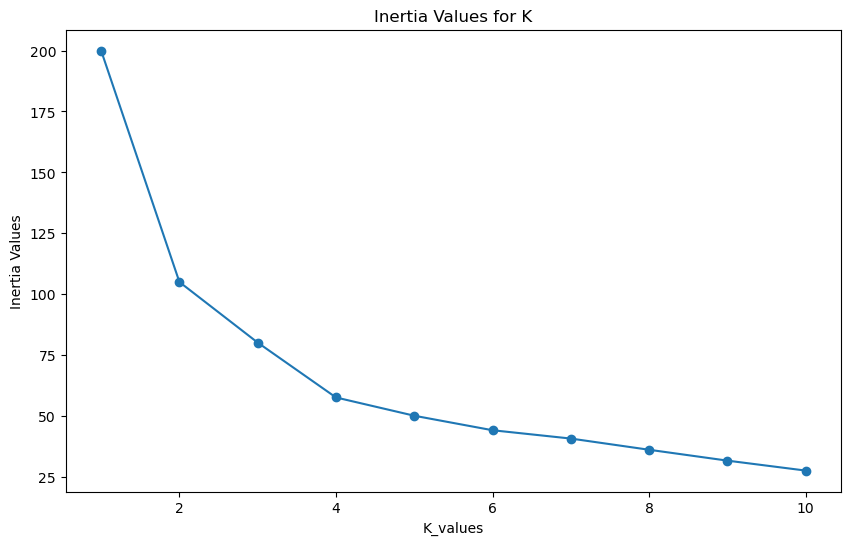

In [131]:
## Elbow plot

plt.figure(figsize= (10, 6))
plt.plot(K_values, inertia_values, marker= "o", linestyle= "-")
plt.title("Inertia Values for K")
plt.xlabel("K_values")
plt.ylabel("Inertia Values")
plt.show()

In [132]:
## Clustering using GMM
BIC_values= []
AIC_values= []
k_values = list(range(1, 11))

for k in k_values:
    Gmm= GaussianMixture(
        n_components= k,
        random_state= 42,
        n_init= 10
    )
    Gmm.fit(usarrests_std)

    BIC_values.append(Gmm.bic(usarrests_std))
    AIC_values.append(Gmm.aic(usarrests_std))

    


c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

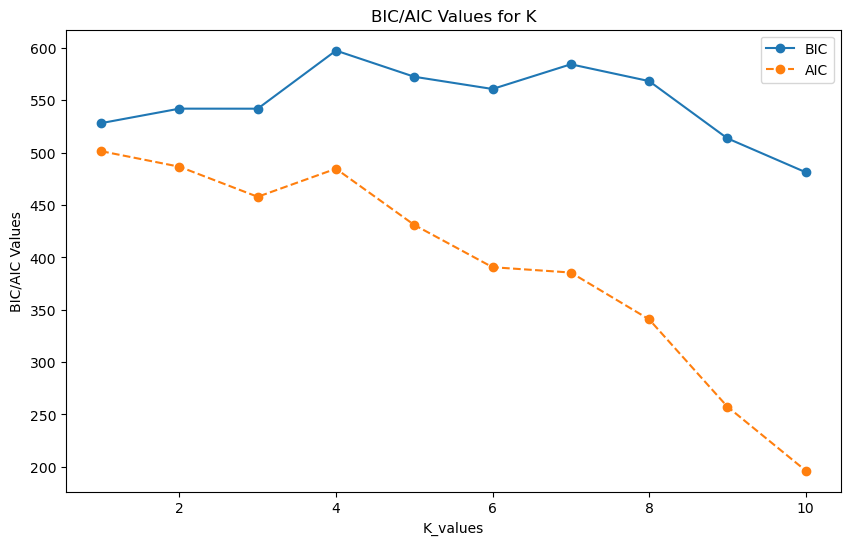

In [133]:
## Plot BIC againsta K_values
plt.figure(figsize= (10, 6))
plt.plot(K_values, BIC_values, marker= "o", linestyle= "-", label= "BIC")
plt.plot(K_values, AIC_values, marker= "o", linestyle= "--", label= "AIC")
plt.title("BIC/AIC Values for K")
plt.xlabel("K_values")
plt.ylabel("BIC/AIC Values")
plt.legend()
plt.show()

In [134]:
## Final models using optimal K's
optimal_k_kmeans = 2
optimal_k_gmm = 3

o_knn = KMeans(
    n_clusters= optimal_k_kmeans,
    random_state= 42,
    n_init= 10
)

usarrests_copy["Kmeans_cluster"] = o_knn.fit_predict(usarrests_std)

o_gmm = GaussianMixture(
    n_components= optimal_k_gmm,
    random_state= 42,
    n_init= 10
)

usarrests_copy["GMM_cluster"] = o_gmm.fit_predict(usarrests_std)
usarrests_copy["GMM_cluster_probability"] = o_gmm.predict_proba(usarrests_std).max(axis= 1)

c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

In [135]:
## Silhoutte scores
print(f"Kmeans Silhoutte score: {silhouette_score(usarrests_std, usarrests_copy["Kmeans_cluster"]):.4}")
print(f"GMM Silhoutte score: {silhouette_score(usarrests_std, usarrests_copy["GMM_cluster"]):.4}")

Kmeans Silhoutte score: 0.4085
GMM Silhoutte score: 0.2132


### Findings
K-Means was selected over GMM because it produced a higher silhouette score, indicating better-defined and more compact clusters for this dataset.<br>

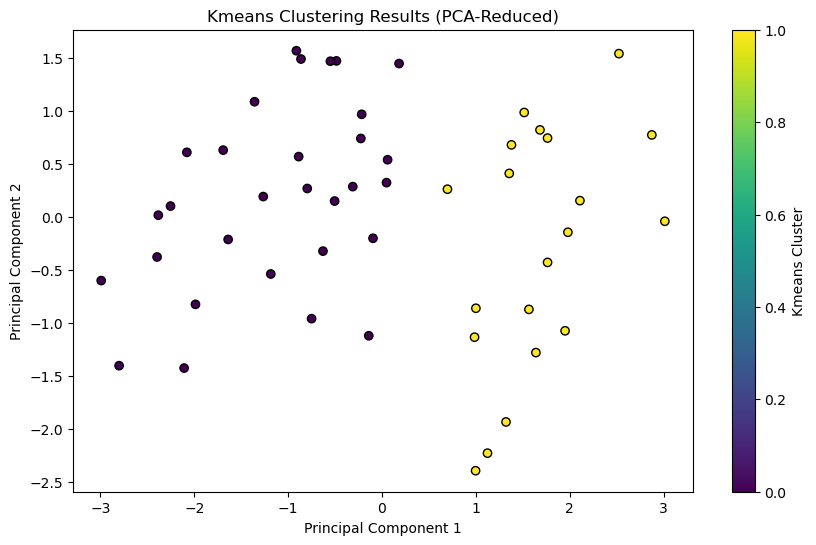

In [136]:
# Using PCA with K means
pca = PCA(n_components=2)
df_pca = pca.fit_transform(usarrests_std)

# plot gmm
plt.figure(figsize=(10, 6))
plt.scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=usarrests_copy["Kmeans_cluster"],
    cmap="viridis",
    marker="o",
    edgecolor="k"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Kmeans Clustering Results (PCA-Reduced)")
plt.colorbar(label="Kmeans Cluster")
plt.show()


#### Interpreting K-Means Clustering (K=2, PCA-Reduced)
What the plot shows:<br>

Clean split along PC1: purple (low crime states) vs. yellow (high crime states) roughly at PC1 ≈ 0.7.<br>
PC1 is almost certainly dominated by the violent crime rates (Murder, Assault, Rape are typically highly correlated in this dataset and load heavily together on PC1), while PC2 likely reflects UrbanPop or a contrast between urbanization and crime rate.<br>
PC2 shows heavy overlap between clusters — meaning urbanization level alone isn't what's separating the two groups; it's the crime-rate axis (PC1) doing the work.<br>
No hard gap between clusters — a handful of points near PC1 ≈ 0.5–1.0 sit close together across colors, so the "boundary" states have crime profiles that are genuinely borderline (neither clearly low- nor high-crime).<br>

### Conclusion

This is a "safe states vs. high-crime states" split. The purple cluster (left) represents states with lower violent crime rates; yellow represents states with higher rates.<br>
K=2 gives a coarse but sensible grouping — states aren't tightly packed into two isolated classes, meaning crime rates vary along a spectrum rather than falling into two distinct "types." This is expected for real-world state-level data.